## 1. Project Overview

Proyek ini menganalisis data penjualan supermarket untuk mengidentifikasi pola penjualan, perilaku pelanggan, distribusi keuntungan, serta peluang bisnis.

## 2. Business Objective

Tujuan dari proyek ini adalah untuk memahami performa penjualan dan keuntungan berdasarkan kategori produk, kota, hari, dan jam, guna mendukung pengambilan keputusan bisnis yang berbasis data.

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
base_path = "/content/drive/MyDrive/sales-analysis-colab/"

import os

folders = [
    f'{base_path}data/raw',
    f'{base_path}data/processed',
    f'{base_path}outputs/figures',
    f'{base_path}outputs/summary'
]

for folder in folders:
  os.makedirs(folder, exist_ok=True)

print("Folder structure created!")

Folder structure created!


In [34]:
import kagglehub

# Download latest version
path_kaggle = kagglehub.dataset_download("faresashraf1001/supermarket-sales")

print("Path to dataset files:", path_kaggle)

Using Colab cache for faster access to the 'supermarket-sales' dataset.
Path to dataset files: /kaggle/input/supermarket-sales


In [35]:
import shutil

shutil.copytree(path_kaggle, f"{base_path}/data/raw/supermarket-sales", dirs_exist_ok=True)

'/content/drive/MyDrive/sales-analysis-colab//data/raw/supermarket-sales'

In [36]:
!ls /content/drive/MyDrive/sales-analysis-colab/data/raw/supermarket-sales

'SuperMarket Analysis.csv'


## 3. Data Understanding

In [37]:
path = "/content/drive/MyDrive/sales-analysis-colab//data/raw/supermarket-sales/SuperMarket Analysis.csv"

import pandas as pd

df = pd.read_csv(path)
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


### Ada berapa baris & kolom?

In [38]:
df.shape

(1000, 17)

### Kolom apa aja?

In [39]:
df.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

### Ada missing value?

In [40]:
df.isnull().sum()

,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Sales,0


### Ada tipe data yang aneh?

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

Dalam dataset terdapat beberapa tipe data yang perlu disesuaikan:

- Kolom 'Date' dan 'Time' perlu dikonversi ke tipe datetime untuk mendukung analisis berbasis waktu.
- Kolom ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment'] dikonversi ke tipe category karena merupakan data kategorikal dan akan digunakan untuk analisis perbandingan antar kategori.

Perubahan tipe data ini bertujuan untuk meningkatkan efisiensi memori serta mempermudah proses analisis dan visualisasi data.

In [42]:
df.describe()

,Unit price,Quantity,Tax 5%,Sales,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


### Ada duplicate?

In [43]:
df.duplicated().sum()

np.int64(0)

## Initial Findings

- Dataset terdiri dari 1000 baris dan 17 kolom, menunjukkan jumlah transaksi yang cukup besar untuk dianalisis.
- Tidak ditemukan missing value, sehingga data dapat langsung dianalisis
- Tidak terdapat duplicate data, yang menunjukan kualitas data cukup baik.
- Data memiliki kombinasi tipe numerik dan object
- Beberapa kolom tipe object akan dilakukan konversi ke kategorikal sehingga memungkinkan analisis baik secara agresi maupun per kategori.
- Kolom Date dan Time akan dikonversi ke DateTime untuk analisis berbasis waktu seperti tren penjualan dan peak hours.




# Data Cleaning

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

## 4. Data Cleaning

In [45]:
df_clean = df.copy()

In [46]:
df_clean.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [47]:
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_clean['Time'] = pd.to_datetime(df_clean['Time'], format='%I:%M:%S %p')

In [48]:
category_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']

for col in category_cols:
  df_clean[col] = df_clean[col].astype('category')

Data sudah di konversi jadi tipe yang dibutuhkan

In [49]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   category      
 2   City                     1000 non-null   category      
 3   Customer type            1000 non-null   category      
 4   Gender                   1000 non-null   category      
 5   Product line             1000 non-null   category      
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-n

In [50]:
# Standardize kategori - menghapus spasi di awal dan akhir teks

df_clean[category_cols] = df_clean[category_cols].apply(lambda x: x.str.strip())

In [51]:
# Feature Engineering - Time-based Features

df_clean['year'] = df_clean['Date'].dt.year # buat kolom tahun

df_clean['month'] = df_clean['Date'].dt.month # buat kolom bulan
df_clean['month_name'] = df_clean['Date'].dt.month_name() # buat nama kolom bulan

df_clean['day'] = df_clean['Date'].dt.day # buat kolom hari
df_clean['day_name'] = df_clean['Date'].dt.day_name() # buat kolom nama hari

df_clean['hour'] = df_clean['Time'].dt.hour # buat kolom jam



In [52]:
df_clean.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,year,month,month_name,day,day_name,hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,2019,1,January,5,Saturday,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,2019,3,March,8,Friday,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,2019,3,March,3,Sunday,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,2019,1,January,27,Sunday,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2019,2,February,8,Friday,10


In [53]:
# Urutkan nama bulan
month_order = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

df_clean['month_name'] = pd.Categorical(
    df_clean['month_name'],
    categories=month_order,
    ordered=True
)

In [54]:
df_clean['month_name'].cat.categories

Index(['January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December'],
      dtype='object')

In [55]:
# Urutkan nama hari

day_order = [
    'Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'
]

df_clean['day_name'] = pd.Categorical(
    df_clean['day_name'],
    categories=day_order,
    ordered=True
)

In [56]:
df_clean['day_name'].cat.categories

Index(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
       'Sunday'],
      dtype='object')

In [57]:
# Save cleaned data

df_clean.to_csv(f'{base_path}data/processed/clean_data.csv', index=False)

## Summary Data Cleaning

- Memverifikasi bahwa tidak terdapat missing values dan data duplikat dalam dataset
- Mengonversi kolom Date dan Time ke tipe datetime untuk mendukung analisis berbasis waktu
- Mengonversi kolom Branch, City, Customer type, Gender, Product line, dan Payment ke tipe kategori untuk meningkatkan konsistensi
- Menstandarisasi nilai kategorikal dengan menghapus spasi di awal dan akhir teks
- Membuat fitur waktu baru (year, month, day, hour, month_name, day_name) untuk mendukung analisis temporal
- Mengurutkan month_name dan day_name agar sesuai dengan urutan kronologis dalam analisis dan visualisasi
- Menyimpan dataset yang telah dibersihkan untuk digunakan pada tahap analisis selanjutnya

# Data EDA + Visualisasi

## 5. Exploratory Data Analysis

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# memunculkan semua kolom df
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

sns.set_style('whitegrid')

In [59]:
df_clean.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,year,month,month_name,day,day_name,hour
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,2019,1,January,5,Saturday,13
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,2019,3,March,8,Friday,10
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,2019,3,March,3,Sunday,13
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,2019,1,January,27,Sunday,20
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2019,2,February,8,Friday,10


### 5.1 Total Sales and Profit

In [60]:
total_sales, total_profit = df_clean[['Sales', 'gross income']].sum()

print(f"Total sales: {total_sales:,.2f}")
print(f"Total profit: {total_profit:,.2f}")

Total sales: 322,966.75
Total profit: 15,379.37


insight :

Bisnis menghasilkan keuntungan dengan margin sekitar 4.76% yang tergolong rendah, menunjukkan model high-volume, low-margin. Karena margin relatif konstan di seluruh produk, peningkatan profit lebih efektif dilakukan dengan mengoptimalkan volume penjualan pada produk dengan kontribusi profit terbesar serta efisiensi biaya operasional.

### 5.2 Sales by Category

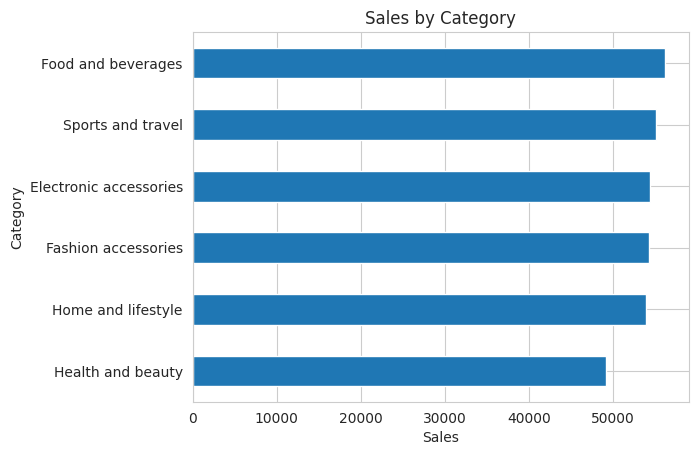

In [61]:
category_sales = df_clean.groupby('Product line')['Sales'].sum().sort_values()

category_sales.plot(kind='barh')
plt.title('Sales by Category')
plt.xlabel('Sales')
plt.ylabel('Category')

plt.savefig(f"{base_path}outputs/figures/Sales_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

insight:

Berdasarkan data, kategori Food and Beverages memiliki total penjualan tertinggi, diikuti oleh Sports and Travel dengan selisih yang relatif kecil. Secara keseluruhan, distribusi penjualan antar kategori cukup merata tanpa adanya dominasi signifikan, menunjukkan bahwa bisnis memiliki struktur pendapatan yang terdiversifikasi.

Kondisi ini mengurangi ketergantungan pada satu kategori, namun juga mengindikasikan belum adanya kategori yang menjadi penggerak utama pertumbuhan. Oleh karena itu, diperlukan analisis lebih lanjut untuk mengidentifikasi kategori dengan potensi profit tertinggi guna dijadikan fokus pengembangan.

### 5.3 Profit by Category

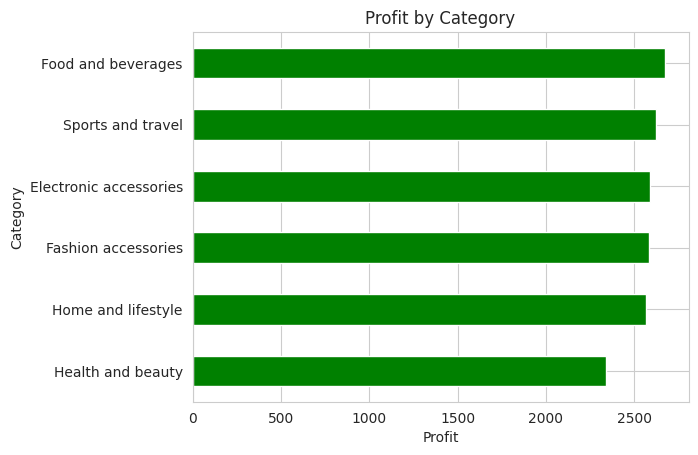

In [62]:
category_profit = df_clean.groupby('Product line')['gross income'].sum().sort_values()

category_profit.plot(kind='barh', color='green')
plt.title('Profit by Category')
plt.ylabel('Category')
plt.xlabel('Profit')
plt.savefig(f"{base_path}outputs/figures/Profit_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

insight:

Grafik profit yang memiliki pola indentik dengan grafik sales menunjukkan bahwa seluruh kategori memiliki margin yang konsisten (~4.76%). Hal ini mengindikasikan tidak ada perbedaan efisiensi profit antar kategori, sehingga peningkatan profit sepenuhnya bergantung pada volume penjualan. Selain itu, diperlukan evaluasi strategi untuk meningkatkan margin guna mendorong profitabilitas yang lebih tinggi.

### 5.4 Data Limitation

Dataset hanya mencakup periode Januari–Maret 2019, sehingga analisis tren jangka panjang belum dapat dilakukan. Oleh karena itu, analisis difokuskan pada pola perilaku penjualan dalam jangka pendek.

### 5.5 Daily Sales Pattern

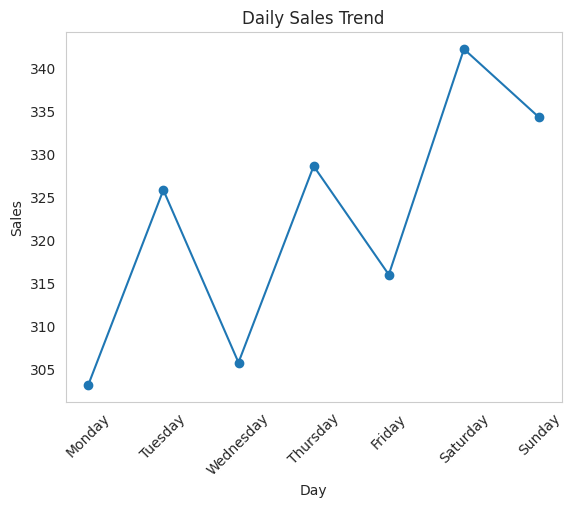

In [63]:
daily_sales = df_clean.groupby('day_name', observed=True)['Sales'].mean().reset_index()

plt.plot(daily_sales['day_name'], daily_sales['Sales'], marker='o')
plt.title("Daily Sales Trend")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid()
plt.savefig(f"{base_path}outputs/figures/Daily_sales_pattern.png", dpi=300, bbox_inches="tight")
plt.show()

insight:

Berdasarkan data, penjualan tertinggi terjadi pada hari Sabtu, diikuti oleh Minggu dan Kamis. Sementara itu, hari Senin dan Rabu menunjukkan volume penjualan yang relatif lebih rendah. Meskipun demikian, perbedaan antar hari relatif kecil (~12%), sehingga menunjukkan bahwa performa penjualan harian cenderung stabil tanpa perbedaan signifikan. Dengan demikian, tidak terdapat hari yang secara dominan menjadi penggerak utama penjualan.

### 5.6 Hourly Sales Pattern

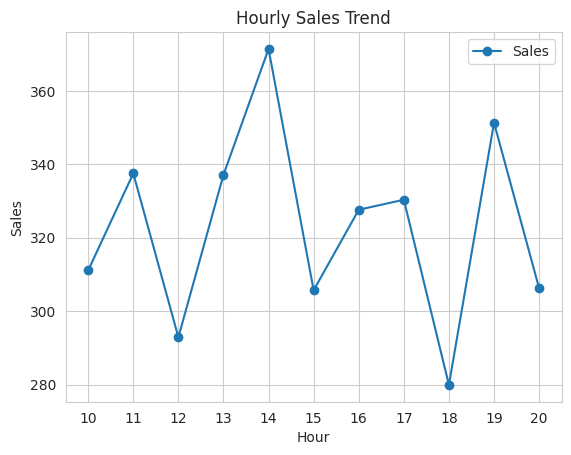

In [64]:
hourly_sales = df_clean.groupby('hour')['Sales'].mean().reset_index()

hourly_sales.plot(x='hour', y='Sales', kind='line', marker='o')
plt.xticks(hourly_sales['hour'])
plt.title("Hourly Sales Trend")
plt.xlabel("Hour")
plt.ylabel("Sales")
plt.savefig(f"{base_path}outputs/figures/Hourly_sales_pattern.png", dpi=300, bbox_inches="tight")
plt.show()

insight:

Pola penjualan menunjukkan kecenderungan peningkatan pada jam istirahat siang dan malam, yang kemungkinan dipengaruhi oleh perilaku konsumen. Meskipun perbedaan antar jam tidak terlalu ekstrem, pola ini tetap menunjukkan adanya variasi perilaku belanja pelanggan sepanjang hari.

### 5.7 Profit by City

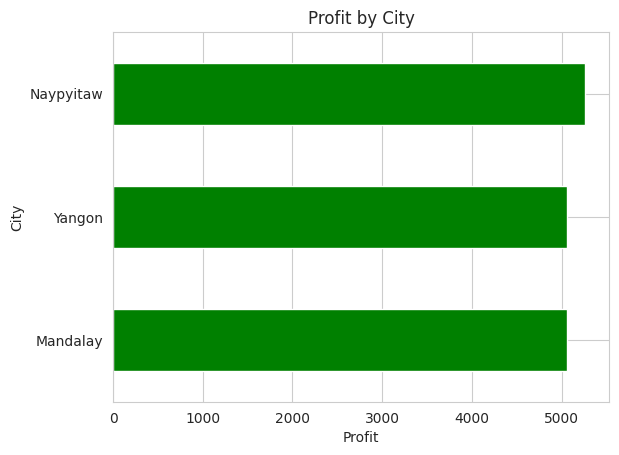

In [65]:
city_profit = df_clean.groupby('City')['gross income'].sum().sort_values()

city_profit.plot( kind='barh', color='green')
plt.title("Profit by City")
plt.xlabel("Profit")
plt.ylabel("City")
plt.savefig(f"{base_path}outputs/figures/Profit_by_city.png", dpi=300, bbox_inches="tight")
plt.show()


insight:

Berdasarkan data, profit antar kota cenderung relatif seimbang tanpa adanya kota yang mendominasi secara signifikan. Hal ini menunjukkan kontribusi profit tersebar cukup merata, sehingga bisnis tidak terlalu bergantung pada satu wilayah tertentu.

### 5.8 Correlation Analysis

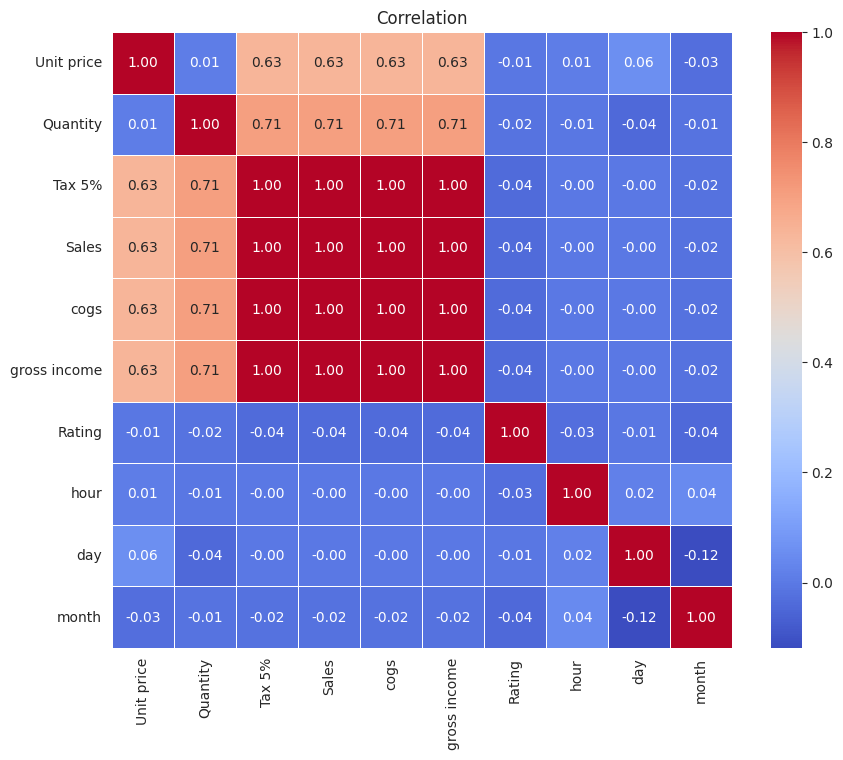

In [66]:
corr_cols = ['Unit price', 'Quantity', 'Tax 5%', 'Sales', 'cogs', 'gross income', 'Rating', 'hour', 'day', 'month']
plt.figure(figsize=(10,8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation")
plt.savefig(f"{base_path}outputs/figures/Correlation_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

insight:

Analisis korelasi menunjukkan bahwa Sales dipengaruhi oleh Quantity dan Unit price, sementara variabel turunan seperti cogs, gross income dan tax 5% memiliki korelasi sempurna karena hubungan matematis. Di sisi lain, faktor seperti Rating dan waktu (jam, hari, bulan) tidak menunjukkan hubungan signifikan terhadap penjualan.

In [67]:
summary = {
    "total_sales": df_clean["Sales"].sum(),
    "total_profit": df_clean["gross income"].sum(),
    "profit_margin": (df_clean["gross income"].sum() / df_clean["Sales"].sum()) * 100,
    "total_transactions": len(df_clean)
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(f"{base_path}outputs/summary/business_summary.csv", index=False)

summary_df

,total_sales,total_profit,profit_margin,total_transactions
0,322966.749,15379.369,4.761905,1000


## 6. Key Insights

1. Penjualan dan profit terutama dipengaruhi oleh Quantity dan Unit Price, sementara margin cenderung konstan di seluruh kategori.
2. Distribusi penjualan dan profit antar kategori serta kota relatif merata, menunjukkan bahwa bisnis tidak bergantung pada satu segmen tertentu.
3. Pola penjualan harian cenderung stabil tanpa perbedaan signifikan antar hari.
4. Analisis per jam menunjukkan adanya peningkatan aktivitas pada jam istirahat siang dan malam.
5. Analisis korelasi menunjukkan bahwa Sales dipengaruhi oleh Quantity dan Unit Price, sementara variabel turunan seperti cogs, gross income, dan Tax 5% memiliki korelasi sempurna karena hubungan matematis.

## 7. Business Recommendations

1. Prioritaskan strategi penjualan pada faktor yang paling mendorong Sales, yaitu Quantity dan Unit Price.
2. Optimalkan kesiapan operasional pada jam puncak, terutama saat istirahat siang dan malam.
3. Evaluasi jam dengan performa lebih rendah untuk mencari peluang peningkatan penjualan secara terbatas.
4. Pertahankan distribusi penjualan yang sudah merata antar kategori dan kota agar bisnis tetap stabil.
5. Interpretasikan hasil korelasi secara hati-hati, terutama pada variabel yang saling terhubung secara matematis.

## 8. Conclusion

Secara keseluruhan, bisnis menunjukkan performa penjualan dan profit yang relatif stabil di berbagai kategori, kota, dan hari. Faktor utama yang mendorong penjualan adalah Quantity dan Unit Price, sementara pola per jam menunjukkan adanya aktivitas yang lebih tinggi pada jam istirahat siang dan malam. Temuan ini menunjukkan bahwa peluang optimasi lebih banyak berada pada strategi volume penjualan dan pengelolaan operasional pada jam-jam tertentu.